# Basic Usage of Diffraction Package

This notebook demonstrates the basic functionality of the diffraction package for X-ray diffraction calculations.

In [1]:
cd ..

/Users/hello/switchdrive/python/claude/diffraction


In [2]:
from diffraction import Crystal

# Load a crystal from CIF file
crystal = Crystal.from_cif("SrTiO3", "diffraction/data/SrTiO3.cif")

# Set orientation relative to laboratory space and calc UB matrix
crystal.add_orientation((0,0,1), (0,0,1), "normal")
crystal.add_orientation((1,0,0), (0,1,0), "inplane along beam")
crystal.calc_ub()

# Set angular constraints
crystal.set_constraints(delta=0, phi=0, eta=0)

print(crystal)

### LATTICE ###
name  : SrTiO3
a     : 3.94513
b     : 3.94513
c     : 3.94513
alpha : 90.0
beta  : 90.0
gamma : 90.0

### UNIT CELL ###
0 (Sr (38), ('1a', (np.float64(0.0), np.float64(0.0), np.float64(0.0))), 1.0, 0.0)
1 (Ti (22), ('1a', (np.float64(0.5), np.float64(0.5), np.float64(0.5))), 1.0, 0.0)
2 (O ( 8), ('1a', (np.float64(0.5), np.float64(0.0), np.float64(0.5))), 1.0, 0.0)
3 (O ( 8), ('1a', (np.float64(0.5), np.float64(0.5), np.float64(0.0))), 1.0, 0.0)
4 (O ( 8), ('1a', (np.float64(0.0), np.float64(0.5), np.float64(0.5))), 1.0, 0.0)

### ORIENTATIONS ###
hkl            xyz            tag
(0, 0, 1)      (0, 0, 1)      normal
(1, 0, 0)      (0, 1, 0)      inplane along beam

### CONSTRAINTS ###
eta   : 0
phi   : 0
delta : 0



In [3]:
# Calculate diffractometer angles for a reflection
angles = crystal.calc_angles((0, 0, 1), 8048.0)
print(angles)

                mu  delta      gamma  eta    chi  phi      theta     ttheta  \
sol. 0  191.259224    0.0  22.518447  0.0  180.0  0.0  11.259224  22.518447   
sol. 1   11.259224    0.0  22.518447  0.0    0.0  0.0  11.259224  22.518447   
sol. 2  -11.259224    0.0 -22.518447  0.0  180.0  0.0  11.259224  22.518447   
sol. 3 -191.259224    0.0 -22.518447  0.0    0.0  0.0  11.259224  22.518447   

          qaz      alpha           naz   tau           psi       beta  \
sol. 0    0.0  78.740776  1.800000e+02  90.0 -1.800000e+02 -78.740776   
sol. 1    0.0 -78.740776  1.773450e-46  90.0 -3.462630e-47  78.740776   
sol. 2  180.0 -78.740776  1.800000e+02  90.0  0.000000e+00  78.740776   
sol. 3  180.0  78.740776  1.773450e-46  90.0  1.800000e+02 -78.740776   

           betain    betaout  
sol. 0  11.259224  11.259224  
sol. 1  11.259224  11.259224  
sol. 2  11.259224  11.259224  
sol. 3  11.259224  11.259224  


In [4]:
# Calculate structure factor
F = crystal.calc_structure_factor((0, 0, 1), 8048.0)
print(f"Structure factor F(001) = {F}")

Structure factor F(001) = (7.291157631497841+0.0077356228806806995j)


## Visualization

### Show the unit cell

In [5]:
vis = crystal.show_unit_cell(browser = "notebook")


Sr1_0 [0. 0. 0.]
Sr1_1 [0.   0.   3.95]
Sr1_2 [0.   3.95 0.  ]
Sr1_3 [0.   3.95 3.95]
Sr1_4 [3.95 0.   0.  ]
Sr1_5 [3.95 0.   3.95]
Sr1_6 [3.95 3.95 0.  ]
Sr1_7 [3.95 3.95 3.95]
Ti1_0 [1.97 1.97 1.97]
O1_0 [1.97 0.   1.97]
O1_1 [1.97 3.95 1.97]
O2_0 [1.97 1.97 0.  ]
O2_1 [1.97 1.97 3.95]
O3_0 [0.   1.97 1.97]
O3_1 [3.95 1.97 1.97]


In [6]:
vis.add_lattice_vectors()

/Users/hello/miniforge3/envs/ana314arm/lib/python3.14/site-packages/spatialgeometry/geom/Shape.py:81: FutureWarning: base kwarg is deprecated, use pose instead
  warn("base kwarg is deprecated, use pose instead", FutureWarning)


In [18]:
arrow.q = (0,0,1,0,0)
vis.env.step()

In [8]:
arrow = visual_primitives.arrow()
vis.env.add(arrow)

/Users/hello/miniforge3/envs/ana314arm/lib/python3.14/site-packages/spatialgeometry/geom/Shape.py:81: FutureWarning: base kwarg is deprecated, use pose instead
  warn("base kwarg is deprecated, use pose instead", FutureWarning)


15

In [30]:
0.2/0.04

5.0

In [16]:
arrow2 = visual_primitives.arrow(length=0.5, scale=0.1)
vis.env.add(arrow2)


16

In [7]:
from diffraction.visualization import visual_primitives
import roboticstoolbox as rtb
import numpy as np
import spatialmath as sm
import spatialgeometry as sg



In [10]:
cone2 = visual_primitives.cone()
cone2.q = (0,0,2,0,0)
vis.env.add(cone2)

18

In [11]:
cone2.q = (0,0,2,0,np.pi)
vis.env.step()

In [11]:
cone.q = (0.3,0,0,0,0)
vis.env.step()

In [7]:


def cone(
    name: str = "cone",
    scale: float | Sequence[float] = 1.0,
    color: Optional[Sequence[float]] = None,
    mesh: str = "cone.stl",
) -> rtb.Robot:
    """Create a visual cone robot from a mesh file.

    The cone points along local +z and uses phi/theta for orientation.

    Args:
        name: Robot name.
        scale: Mesh scale factor (scalar or [sx, sy, sz]).
        color: RGB or RGBA tuple/list for the cone color.
        mesh: Filename of the cone mesh (default "cone.stl").

    Returns:
        rtb.Robot with q = [x, y, z, phi, theta].

    Raises:
        ValueError: If scale is not a scalar or 3-element sequence.
    """
    color = visual_primitives._as_color(color)

    if isinstance(scale, (list, tuple)):
        if len(scale) != 3:
            raise ValueError("scale must be a scalar or a 3-vector [sx, sy, sz]")
        scale_vec = [float(v) for v in scale]
    else:
        s = float(scale)
        scale_vec = [s, s, s]

    base = rtb.Link(name="base")
    x = rtb.Link(rtb.ET.tx(), name="x", parent=base, qlim=(-1000, 1000))
    y = rtb.Link(rtb.ET.ty(), name="y", parent=x, qlim=(-1000, 1000))
    z = rtb.Link(rtb.ET.tz(), name="z", parent=y, qlim=(-1000, 1000))

    phi = rtb.Link(rtb.ET.Rz(), name="phi", parent=z)
    theta = rtb.Link(rtb.ET.Ry(), name="theta", parent=phi)

    mesh_file = visual_primitives._mesh_path(mesh)
    cone_local_pose = sm.SE3.Tz(scale_vec[2] / 2.0).A

    geom = sg.Mesh(filename=mesh_file)
    cone_link = rtb.Link(name="cone", parent=theta, geometry=[geom])

    robot = rtb.Robot([base, x, y, z, phi, theta, cone_link], name=name)
    robot.q = np.zeros(5)
    return robot


In [28]:
test.q = (0.5,0,0,0.0, 0.5)
vis.env.step()

'/Users/hello/switchdrive/python/claude/diffraction/diffraction/visualization/cone.stl'

In [12]:
import spatialgeometry as sg


In [14]:
cone_geom = sg.Mesh(visual_primitives._mesh_path('cone.stl'))

In [15]:
cone_geom

mesh,
[0. 0. 0.]

In [7]:
cone = visual_primitives.cone(scale=0.1)

/Users/hello/miniforge3/envs/ana314arm/lib/python3.14/site-packages/spatialgeometry/geom/Shape.py:81: FutureWarning: base kwarg is deprecated, use pose instead
  warn("base kwarg is deprecated, use pose instead", FutureWarning)


In [10]:
test

ERobot: cylinder, 5 joints (PPPRR), geometry
┌──────┬───────────┬───────┬────────┬─────────────────────┐
│ link │   link    │ joint │ parent │ ETS: parent to link │
├──────┼───────────┼───────┼────────┼─────────────────────┤
│    0 │ base      │       │ BASE   │ SE3()               │
│    1 │ x         │     0 │ base   │ tx(q0)              │
│    2 │ y         │     1 │ x      │ ty(q1)              │
│    3 │ z         │     2 │ y      │ tz(q2)              │
│    4 │ phi       │     3 │ z      │ Rz(q3)              │
│    5 │ theta     │     4 │ phi    │ Ry(q4)              │
│    6 │ @cylinder │       │ theta  │ SE3()               │
└──────┴───────────┴───────┴────────┴─────────────────────┘

In [8]:
v

ERobot: cone, 5 joints (PPPRR), geometry
┌──────┬───────┬───────┬────────┬─────────────────────┐
│ link │ link  │ joint │ parent │ ETS: parent to link │
├──────┼───────┼───────┼────────┼─────────────────────┤
│    0 │ base  │       │ BASE   │ SE3()               │
│    1 │ x     │     0 │ base   │ tx(q0)              │
│    2 │ y     │     1 │ x      │ ty(q1)              │
│    3 │ z     │     2 │ y      │ tz(q2)              │
│    4 │ phi   │     3 │ z      │ Rz(q3)              │
│    5 │ theta │     4 │ phi    │ Ry(q4)              │
│    6 │ @cone │       │ theta  │ SE3()               │
└──────┴───────┴───────┴────────┴─────────────────────┘

In [ ]:
vis.env.add(cone)

In [9]:
test = visual_primitives.cylinder()

In [8]:
vis.env.add(test)

15

In [16]:
test.q=np.array([0,0,0,np.pi/4,np.pi/4])
vis.env.step()

In [12]:
test.q=(0.3,0.3,0.3)

In [16]:
test.

In [ ]:
dt = 0.02

for k in range(1000):
    t = k * dt

    x = 0.2 * np.sin(t)
    y = 0.2 * np.cos(t)
    z = 0.5

    phi = t
    theta = np.pi / 4 + 0.25 * np.sin(2 * t)

    cyl.q = np.array([x, y, z, phi, theta])

    vis.env.step(dt)

connection handler failed
Traceback (most recent call last):
  File "/Users/hello/miniforge3/envs/ana314arm/lib/python3.14/asyncio/selector_events.py", line 1071, in write
    n = self._sock.send(data)
BrokenPipeError: [Errno 32] Broken pipe

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/Users/hello/miniforge3/envs/ana314arm/lib/python3.14/site-packages/websockets/asyncio/server.py", line 376, in conn_handler
    await self.handler(connection)
  File "/Users/hello/miniforge3/envs/ana314arm/lib/python3.14/site-packages/swift/SwiftRoute.py", line 324, in serve
    await self.expect_message(websocket, expected)
  File "/Users/hello/miniforge3/envs/ana314arm/lib/python3.14/site-packages/swift/SwiftRoute.py", line 329, in expect_message
    recieved = await websocket.recv()
               ^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/hello/miniforge3/envs/ana314arm/lib/python3.14/site-packages/websockets/asyncio/connection.py", lin

In [91]:
vis.env.swift_objects[-5].links[-1].geometry[0].color = (np.float64(1.0), np.float64(.3), np.float64(0.0), np.float64(1.0))

In [92]:
vis.env.step()

In [76]:
dt = 0.02

for k in range(500):
    t = k * dt

    x = 0.0
    y = 0.0
    z = 0.0

    phi = t
    theta = np.pi / 4 + 0.2 * np.sin(t)

    vis.env.swift_objects[-1].base = cylinder_pose_from_spherical(x, y, z, phi, theta, r).A

    vis.env.step(dt)

In [9]:
import swift

In [24]:
import roboticstoolbox as rtb
import numpy as np


In [97]:
cyl = cylinder_dynamic(
    length=1.0,
    radius=0.025,
)

vis.env.add(cyl)

# q = [x, y, z, phi, theta]


15

In [99]:
cyl.q = np.array([0.0, 0.0, 0.0, 0.0, np.pi / 4])
vis.env.step(0)

In [17]:
import swift
import spatialgeometry as sg
import spatialmath as sm
import numpy as np

def cylinder_static(x, y, z, phi, theta, length):
    """
    Cylinder is assumed to be aligned with local +z.
    The pose places its base at (x, y, z) and its center at length/2.
    """
    return (
        sm.SE3(x, y, z)
        * sm.SE3.Rz(phi)
        * sm.SE3.Ry(theta)
        * sm.SE3.Tz(length / 2)
    )

cyl = sg.Cylinder(
    radius=width / 2,
    length=r,
    base=cylinder_pose_from_spherical(x, y, z, phi, theta, r).A
)

import numpy as np
import roboticstoolbox as rtb
import spatialgeometry as sg
import spatialmath as sm
import swift


def cylinder_dynamic(
    name="vector_cylinder",
    length=1.0,
    radius=0.025,
    color=(1.0, 0.607843137255, 0.0, 1.0),
):
    """
    Create a 5-DOF visual cylinder robot:

        q[0] = x translation
        q[1] = y translation
        q[2] = z translation
        q[3] = phi, rotation about z
        q[4] = theta, rotation about y

    The cylinder starts at the controlled origin and extends along local +z.
    """

    # Cylinder geometry.
    # The base transform offsets the visual geometry by length/2,
    # so the link frame sits at the cylinder's lower/base endpoint.
    cylinder_geom = sg.Cylinder(
        radius=radius,
        length=length,
        base=sm.SE3.Tz(length / 2).A,
        color=color,
    )

    # Root/base link: no joint variable
    base = rtb.ELink(name="base")

    # Variable elementary transforms become joints.
    # ET.tx(), ET.ty(), ET.tz() without an argument are variable translations.
    # ET.Rz(), ET.Ry() without an argument are variable rotations.
    x_link = rtb.ELink(
        rtb.ET.tx(),
        name="x_link",
        parent=base,
        qlim=[-1000, 1000],
    )

    y_link = rtb.ELink(
        rtb.ET.ty(),
        name="y_link",
        parent=x_link,
        qlim=[-1000, 1000],
    )

    z_link = rtb.ELink(
        rtb.ET.tz(),
        name="z_link",
        parent=y_link,
        qlim=[-1000, 1000],
    )

    phi_link = rtb.ELink(
        rtb.ET.Rz(),
        name="phi_link",
        parent=z_link,
    )

    theta_link = rtb.ELink(
        rtb.ET.Ry(),
        name="theta_link",
        parent=phi_link,
        geometry=[cylinder_geom],
    )

    robot = rtb.ERobot(
        [base, x_link, y_link, z_link, phi_link, theta_link],
        name=name,
    )

    return robot


NameError: name 'width' is not defined

In [18]:
vis.env.swift_objects[0]


ERobot: Oxygen, 3 joints (PPP), geometry
┌──────┬──────┬───────┬────────┬─────────────────────┐
│ link │ link │ joint │ parent │ ETS: parent to link │
├──────┼──────┼───────┼────────┼─────────────────────┤
│    0 │ base │       │ BASE   │ SE3()               │
│    1 │ x    │     0 │ base   │ SE3() ⊕ tx(q0)      │
│    2 │ y    │     1 │ x      │ SE3() ⊕ ty(q1)      │
│    3 │ @z   │     2 │ y      │ SE3() ⊕ tz(q2)      │
└──────┴──────┴───────┴────────┴─────────────────────┘

In [66]:
vis.env.add(test)

19

In [59]:
geometry.T


array([[1., 0., 0., 0.],
       [0., 1., 0., 0.],
       [0., 0., 1., 0.],
       [0., 0., 0., 1.]])

In [39]:
link.m

0.0

In [17]:
vis.add_white_planes()

In [7]:
from pathlib import Path
import re
import shutil
import swiftCould not find Next.js index bundle below {swift_dir}"import swift
        )

    patched = []

    for js_file in candidates:
        text = js_file.read_text(encoding="utf-8", errors="replace")

        # This identifies the exact minified component we found:
        # var dL=function(){var e=uu().scene;return ...},dR=function(...)
        pattern = r"var dL=function\(\)\{var e=uu\(\)\.scene;return .*?\},dR=function"

        if not re.search(pattern, text):
            continue

        backup = js_file.with_suffix(js_file.suffix + ".bak")
        if not backup.exists():
            shutil.copy2(js_file, backup)

        if disable_floor:
            fog_expr = "null" if disable_fog else f"new iT({background_decimal},50,60)"

            replacement = (
                f"var dL=function(){{"
                f"var e=uu().scene;"
                f"return e.background=new eh({background_decimal}),"
                f"e.fog={fog_expr},"
                f"null"
                f"}},dR=function"
            )

            new_text = re.sub(pattern, replacement, text)
        else:
            # Keep the floor but recolor background/fog/floor.
            new_text = text
            new_text = new_text.replace("new eh(7895160)", f"new eh({background_decimal})")
            new_text = new_text.replace("new iT(7895160,50,60)", f"new iT({background_decimal},50,60)")
            new_text = new_text.replace("color:4934475", f"color:{background_decimal}")

        js_file.write_text(new_text, encoding="utf-8")
        patched.append((js_file, backup))

    if not patched:
        raise RuntimeError(
            "Found index bundle(s), but could not find the Swift environment component."
        )

    return patched


def restore_swift_frontend_environment(patched_files):
    """
    Restore files patched by patch_swift_frontend_environment().
    """
    for js_file, backup in patched_files:
        if backup.exists():
            shutil.copy2(backup, js_file)


def patch_swift_frontend_environment(
    background_decimal=16777215,  # white: 0xffffff
    disable_fog=True,
    disable_floor=True,
):
    """
    Patch the installed Swift frontend bundle in-place.

    Returns a list of backup files that can later be restored.
    """

    swift_dir = Path(swift.__file__).resolve().parent

    candidates = list(swift_dir.rglob("index-*.js"))

    if not candidates:
        raise FileNotFoundError(


{0: ERobot: Plane, 3 joints (PPP), geometry
 ┌──────┬──────┬───────┬────────┬─────────────────────┐
 │ link │ link │ joint │ parent │ ETS: parent to link │
 ├──────┼──────┼───────┼────────┼─────────────────────┤
 │    0 │ base │       │ BASE   │ SE3()               │
 │    1 │ x    │     0 │ base   │ SE3() ⊕ tx(q0)      │
 │    2 │ y    │     1 │ x      │ SE3() ⊕ ty(q1)      │
 │    3 │ @z   │     2 │ y      │ SE3() ⊕ tz(q2)      │
 └──────┴──────┴───────┴────────┴─────────────────────┘,
 1: ERobot: Plane, 3 joints (PPP), geometry
 ┌──────┬──────┬───────┬────────┬─────────────────────┐
 │ link │ link │ joint │ parent │ ETS: parent to link │
 ├──────┼──────┼───────┼────────┼─────────────────────┤
 │    0 │ base │       │ BASE   │ SE3()               │
 │    1 │ x    │     0 │ base   │ SE3() ⊕ tx(q0)      │
 │    2 │ y    │     1 │ x      │ SE3() ⊕ ty(q1)      │
 │    3 │ @z   │     2 │ y      │ SE3() ⊕ tz(q2)      │
 └──────┴──────┴───────┴────────┴─────────────────────┘,
 2: ERobot: Pl

### Load previously saved crystal

In [3]:
crystal = Crystal.load("LiNbO3_2")

In [6]:
vis = crystal.show_unit_cell(browser = None)

Li1_0 [1.2  1.75 3.3 ]
Li2_0 [3.32 4.84 9.13]
Nb1_0 [-0. -0. -0.]
Nb1_1 [-0.   -0.    5.49]
Nb1_2 [-0.    4.55  3.08]
Nb1_3 [-0.    4.55  8.57]
Nb1_4 [4.24 1.63 3.08]
Nb1_5 [4.24 1.63 8.57]
Nb1_6 [4.24 6.18 6.16]
Nb1_7 [ 4.24  6.18 11.66]
Nb2_0 [2.12 3.09 5.83]
O1_0 [0.49 1.82 5.42]
O2_0 [1.52 3.86 3.96]
O3_0 [2.61 2.01 7.29]
O4_0 [3.06 1.7  4.54]
O5_0 [0.94 4.26 6.71]
O6_0 [3.64 4.2  5.76]


In [5]:
import numpy as np
n = np.linspace(0,20*np.pi,250)
amplitudes = 0.5* np.array([np.sin(n), np.cos(n)])
amplitudes = 0.5* np.array(np.sin(n))
#v = crystal.phonons.get_mode('A4').vectors
crystal.phonons.show(mode_name='A4', vis=vis)
#vis.animate(vectors=v, amplitudes=amplitudes)

Showing default animation of phonon mode 'A4'


In [7]:
v

array([[ 0.024, -0.048,  0.024],
       [-0.031,  0.044, -0.014],
       [-0.026,  0.027,  0.   ],
       [ 0.01 , -0.034,  0.025],
       [ 0.005,  0.077, -0.036],
       [ 0.076, -0.004,  0.026],
       [-0.024, -0.125, -0.068],
       [ 0.095, -0.01 ,  0.035],
       [ 0.04 ,  0.107,  0.014],
       [-0.091,  0.001, -0.117]])

In [10]:
np.array([v])

array([[[ 0.024, -0.048,  0.024],
        [-0.031,  0.044, -0.014],
        [-0.026,  0.027,  0.   ],
        [ 0.01 , -0.034,  0.025],
        [ 0.005,  0.077, -0.036],
        [ 0.076, -0.004,  0.026],
        [-0.024, -0.125, -0.068],
        [ 0.095, -0.01 ,  0.035],
        [ 0.04 ,  0.107,  0.014],
        [-0.091,  0.001, -0.117]]])

In [8]:
np.atleast_3d(v)

array([[[ 0.024],
        [-0.048],
        [ 0.024]],

       [[-0.031],
        [ 0.044],
        [-0.014]],

       [[-0.026],
        [ 0.027],
        [ 0.   ]],

       [[ 0.01 ],
        [-0.034],
        [ 0.025]],

       [[ 0.005],
        [ 0.077],
        [-0.036]],

       [[ 0.076],
        [-0.004],
        [ 0.026]],

       [[-0.024],
        [-0.125],
        [-0.068]],

       [[ 0.095],
        [-0.01 ],
        [ 0.035]],

       [[ 0.04 ],
        [ 0.107],
        [ 0.014]],

       [[-0.091],
        [ 0.001],
        [-0.117]]])

In [13]:
np.asarray([amplitudes]).shape

(1, 500)

In [15]:
np.atleast_2d(amplitudes).shape

(1, 500)

### Animate atoms along a linear combination of two displacement vectors

In [6]:
import numpy as np

# Create exemplary displacement vectors along x and y directions

displacement_vector_x = {
    "Sr1": [0.01, 0, 0],
    "Ti1": [0.03, 0, 0],
    "O1": [-0.1, 0, 0],
    "O2": [-0.1, 0, 0],
    "O3": [-0.1, 0, 0],
}

vector_x = [] # Take care of multiplicity
for (atom, displacement), mult in zip(displacement_vector_x.items(), vis.multiplicity):
    for n in range(mult):
        vector_x.append(displacement)
vector_x = np.array(vector_x)

displacement_vector_y = {
    "Sr1": [0, 0.01, 0],
    "Ti1": [0, 0.03, 0],
    "O1": [0, -0.1, 0],
    "O2": [0, -0.1, 0],
    "O3": [0, -0.1, 0],
}

vector_y = [] # Take care of multiplicity
for (atom, displacement), mult in zip(displacement_vector_y.items(), vis.multiplicity):
    for n in range(mult):
        vector_y.append(displacement)
vector_y = np.array(vector_y)

In [7]:
# Create exemplary displacement amplitudes
n = np.linspace(0,20*np.pi,500)
amplitudes = 0.5* np.array([np.sin(n), np.cos(n)])

In [9]:
# Start animation
vis = crystal.show_unit_cell(browser="notebook")
vis.animate(vectors=[vector_x, vector_y], amplitudes=amplitudes, dt=0.01, scale=1)

Sr1_0 [0. 0. 0.]
Sr1_1 [0.   0.   3.95]
Sr1_2 [0.   3.95 0.  ]
Sr1_3 [0.   3.95 3.95]
Sr1_4 [3.95 0.   0.  ]
Sr1_5 [3.95 0.   3.95]
Sr1_6 [3.95 3.95 0.  ]
Sr1_7 [3.95 3.95 3.95]
Ti1_0 [1.97 1.97 1.97]
O1_0 [1.97 0.   1.97]
O1_1 [1.97 3.95 1.97]
O2_0 [1.97 1.97 0.  ]
O2_1 [1.97 1.97 3.95]
O3_0 [0.   1.97 1.97]
O3_1 [3.95 1.97 1.97]


### Plot constraint sensitivity of diffraction angles
- Calculate the sensitivty of the diffraction angle sweeping one of the constraints

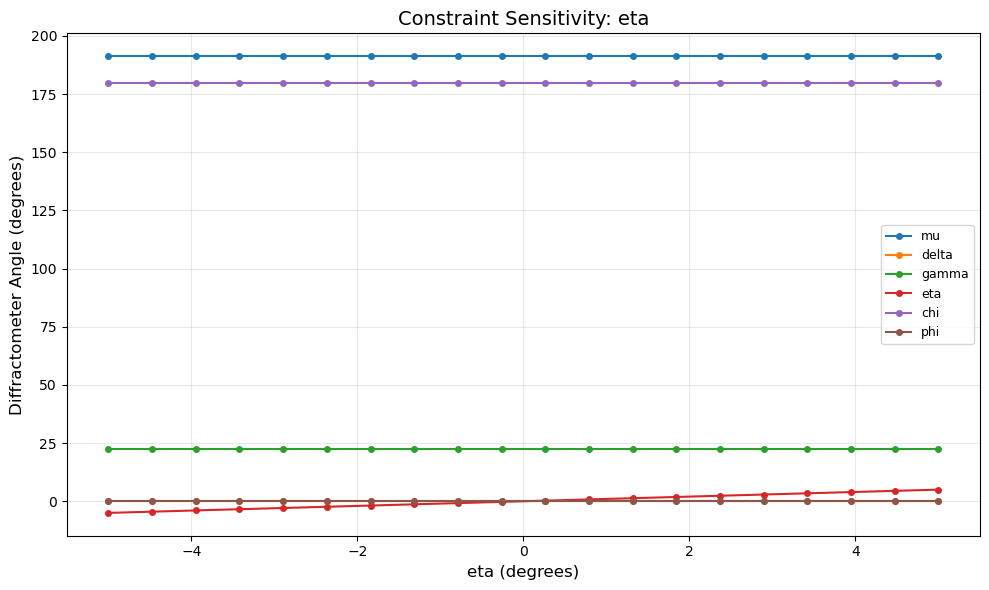

In [5]:
import diffraction.visualization as vis
fig, ax, x_values, results = vis.angular_solutions.plot_constraint_sensitivity(crystal, (0,0,1), 8000, 0, "eta",  -5,5)